# Week 6 — Project 2: GNN for the Spillover Network (China Market)
**Owner:** Student A — Line A (spillover dynamics) + Line B (DY-GCN / GAT volatility forecasting)

This notebook ingests Week 3 (VAR/DY connectedness) and Week 4 (EPU/TPU policy uncertainty) outputs and
implements the full Line A analysis plus the three-way HAR / DY-GCN / GAT forecasting comparison for Project 2.

**Assumption flagged for review:** the planner specifies the volatility panel and policy-index paths exactly,
but does not give an explicit file for the *rolling DY FEVD matrix series* (only "dynamic row-normalized 11x11
matrices"). This notebook assumes Week 3 exported them to
`outputs/{market}/dy_fevd_matrices.npz` (keys: `dates`, `matrices` shape `(T, 11, 11)`).
If your actual Week 3 export uses a different filename, change `DY_MATRIX_PATH` in Cell 2 only.

If any of the three upstream files are missing, `SYNTHETIC_MODE` auto-activates so the notebook still
runs end-to-end for structural testing — flip it off once real Week 3/4 outputs are in place.


Run this in terminal before importing:

```bash
pip install numpy ipykernel
pip install pandas ipykernel
pip install statsmodels ipykernel
pip install arch ipykernel
pip install openpyxl
pip install matplotlib 
pip install seaborn
pip install torch
pip install scikit-learn
```

In [4]:
# Cell 1 — Imports
import os, json, math, warnings, itertools
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.nn import GCNConv, GATConv
    from torch_geometric.data import Data
    HAS_PYG = True
except Exception:
    HAS_PYG = False
    print("torch_geometric not found — GCN/GAT cells will fall back to a dense-matmul implementation "
          "(functionally equivalent for a fixed 11-node graph, just not batched via PyG Data objects).")

from scipy import stats
from sklearn.preprocessing import StandardScaler
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

warnings.filterwarnings("ignore")
np.random.seed(0)
torch.manual_seed(0)


torch_geometric not found — GCN/GAT cells will fall back to a dense-matmul implementation (functionally equivalent for a fixed 11-node graph, just not batched via PyG Data objects).


In [5]:
# Cell 2 — Configuration & Path Registry (Line A + Line B shared)
MARKET = "china"  # 🧪 EXPERIMENTATION HANDLE: [WHAT: market key | WHY: notebook is dual-market ready per Week4/5
                  #  conventions | HOW: switch to "us" to rerun the entire pipeline on the US panel]

BASE = Path("outputs") / MARKET
VOL_PANEL_PATH   = BASE / "garch_volatility_panel.csv"     # 11 GICS sector conditional-vol columns, daily
POLICY_PATH      = BASE / "rolling_tsi.csv"                # EPU, TPU daily indices
DY_MATRIX_PATH   = BASE / "dy_fevd_matrices.npz"           # ASSUMPTION — see intro markdown cell

SECTORS = ["Energy","Materials","Industrials","ConsumerDiscretionary","ConsumerStaples",
           "HealthCare","Financials","InformationTechnology","CommunicationServices",
           "Utilities","RealEstate"]  # standard 11 GICS sectors, must match panel column order

HORIZON = 10          # 🧪 EXPERIMENTATION HANDLE: [WHAT: DY FEVD forecast horizon | WHY: connectedness is
                      #  horizon-sensitive | HOW: must match whatever horizon Week3 used to build DY_MATRIX_PATH;
                      #  purely informational here since matrices are pre-computed upstream]
ROLLING_WINDOW = 200  # 🧪 EXPERIMENTATION HANDLE: [WHAT: rolling window Week3 used | WHY: same reason as above |
                      #  HOW: informational unless you regenerate matrices in this notebook]

LOOKBACK_HAR = {"D": 1, "W": 5, "M": 22}  # 🧪 EXPERIMENTATION HANDLE: [WHAT: HAR component windows | WHY: HAR
                                          #  fit quality is very sensitive to these | HOW: try {"D":1,"W":5,"M":66}
                                          #  for a slower macro cycle]

TRAIN_FRAC, VAL_FRAC = 0.60, 0.20  # 🧪 EXPERIMENTATION HANDLE: [WHAT: chronological split ratios | WHY: China
                                   # market regime shifts (2015 crash, 2020 covid) sit at different points in the
                                   # sample | HOW: shift ratios to keep a stress regime inside test set deliberately]

STRESS_WINDOWS = {  # used by shock-reconstruction module in Line A
    "GFC_2008": ("2008-08-01", "2009-06-30"),
    "COVID_2020": ("2020-01-15", "2020-06-30"),
}  # 🧪 EXPERIMENTATION HANDLE: [WHAT: macro stress windows | WHY: China-specific stress dates differ from US
   # (e.g. 2015-08 A-share crash, 2018 trade-war escalation) | HOW: add "CN_2015_Crash": ("2015-06-01","2016-02-29")
   # or "TradeWar_2018": ("2018-03-01","2018-12-31") to widen shock coverage]

SYNTHETIC_MODE = not (VOL_PANEL_PATH.exists() and POLICY_PATH.exists() and DY_MATRIX_PATH.exists())
print(f"Market: {MARKET} | SYNTHETIC_MODE={SYNTHETIC_MODE}")


Market: china | SYNTHETIC_MODE=True


In [6]:
# Cell 3 — Data Ingestion (with synthetic fallback so the notebook is runnable out-of-the-box)
def _make_synthetic(n_days=1200, n_sectors=11, seed=7):
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range("2016-01-04", periods=n_days)
    # correlated GARCH-like vol panel
    base = np.abs(rng.standard_t(df=5, size=(n_days, n_sectors))) * 0.01
    shocks = np.cumsum(rng.normal(0, 0.0005, size=(n_days, n_sectors)), axis=0)
    vol_panel = pd.DataFrame(base + np.abs(shocks), index=dates, columns=SECTORS)
    policy = pd.DataFrame({
        "EPU": 100 + np.cumsum(rng.normal(0, 3, size=n_days)),
        "TPU": 100 + np.cumsum(rng.normal(0, 4, size=n_days)),
    }, index=dates)
    # rolling row-normalized DY FEVD matrices: start from a random connectedness structure, add slow drift
    T = n_days
    base_mat = rng.dirichlet(np.ones(n_sectors), size=n_sectors)  # rows sum to 1
    mats = np.zeros((T, n_sectors, n_sectors))
    for t in range(T):
        drift = rng.normal(0, 0.01, size=(n_sectors, n_sectors))
        m = np.clip(base_mat + drift * (t / T), 0, None)
        m = m / m.sum(axis=1, keepdims=True)
        mats[t] = m
        base_mat = m
    return vol_panel, policy, dates, mats

if SYNTHETIC_MODE:
    vol_panel, policy_df, dy_dates, dy_matrices = _make_synthetic()
else:
    vol_panel = pd.read_csv(VOL_PANEL_PATH, index_col=0, parse_dates=True)[SECTORS]
    policy_df = pd.read_csv(POLICY_PATH, index_col=0, parse_dates=True)[["EPU", "TPU"]]
    dy_npz = np.load(DY_MATRIX_PATH, allow_pickle=True)
    dy_dates = pd.to_datetime(dy_npz["dates"])
    dy_matrices = dy_npz["matrices"]

# align all three sources on the common date index
common_idx = vol_panel.index.intersection(policy_df.index).intersection(pd.Index(dy_dates))
vol_panel = vol_panel.loc[common_idx].sort_index()
policy_df = policy_df.loc[common_idx].sort_index()
date_to_pos = {d: i for i, d in enumerate(dy_dates)}
dy_matrices = np.stack([dy_matrices[date_to_pos[d]] for d in common_idx])

print(vol_panel.shape, policy_df.shape, dy_matrices.shape)
vol_panel.tail()


(1200, 11) (1200, 2) (1200, 11, 11)


,Energy,Materials,Industrials,ConsumerDiscretionary,ConsumerStaples,HealthCare,Financials,InformationTechnology,CommunicationServices,Utilities,RealEstate
2020-08-03,0.040842,0.003812,0.042156,0.011901,0.009378,0.013498,0.014995,0.032210,0.020592,0.018640,0.039934
2020-08-04,0.029732,0.002954,0.008654,0.005985,0.007543,0.001435,0.017597,0.018093,0.024540,0.025248,0.026596
2020-08-05,0.037324,0.005142,0.019113,0.025485,0.006286,0.010190,0.024390,0.028679,0.026343,0.032799,0.019494
2020-08-06,0.044595,0.003653,0.014675,0.006681,0.010907,0.001699,0.012489,0.023767,0.004070,0.017881,0.029288
2020-08-07,0.031830,0.010344,0.010517,0.016136,0.013307,0.006259,0.015360,0.023626,0.006944,0.025859,0.024616


## Part 1 — Line A: Spillover Dynamics & Analysis

In [7]:
# Cell 4 — Net Directional Spillover Table (TO minus FROM per sector)
# Convention: row i = "from" sector, col j = "to" sector contribution in the row-normalized FEVD matrix,
# so FROM_i = sum_j (matrix[i, j] for j != i) and TO_i = sum_j (matrix[j, i] for j != i).
n = len(SECTORS)
off_diag_mask = ~np.eye(n, dtype=bool)

to_series = dy_matrices.transpose(0, 2, 1)[:, :, :] * off_diag_mask  # zero the diagonal, keep TO-orientation
to_total = to_series.sum(axis=1)          # (T, n) — total TO_i(t)
from_total = (dy_matrices * off_diag_mask).sum(axis=2)  # (T, n) — total FROM_i(t)
net_total = to_total - from_total          # (T, n) — NET_i(t)

net_df = pd.DataFrame(net_total, index=vol_panel.index, columns=SECTORS)
to_df = pd.DataFrame(to_total, index=vol_panel.index, columns=SECTORS)
from_df = pd.DataFrame(from_total, index=vol_panel.index, columns=SECTORS)

net_directional_table = pd.DataFrame({
    "TO": to_df.mean(),
    "FROM": from_df.mean(),
    "NET": net_df.mean(),
}).sort_values("NET", ascending=False)
net_directional_table


,TO,FROM,NET
RealEstate,0.970202,0.970202,4.996004e-18
CommunicationServices,0.915984,0.915984,1.942890e-18
ConsumerStaples,0.951850,0.951850,1.202742e-18
Financials,0.959230,0.959230,4.625929e-19
Utilities,0.915874,0.915874,9.251859e-20
Industrials,0.945481,0.945481,-9.251859e-20
HealthCare,0.953336,0.953336,-5.551115e-19
Energy,0.955043,0.955043,-7.401487e-19
InformationTechnology,0.966065,0.966065,-2.035409e-18
Materials,0.859803,0.859803,-2.590520e-18


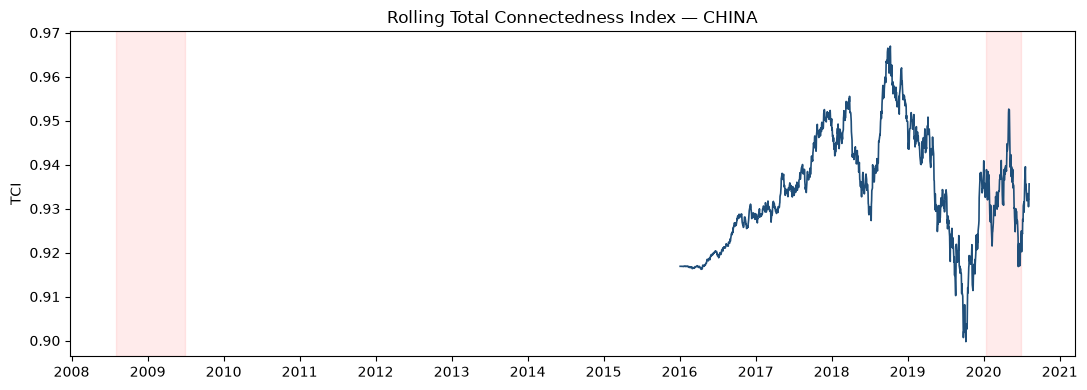

In [8]:
# Cell 5 — Rolling Total Connectedness Index (TCI) trajectory
# TCI(t) = average off-diagonal contribution across the system (standard Diebold-Yilmaz TCI definition)
tci = (dy_matrices * off_diag_mask).sum(axis=(1, 2)) / n
tci_series = pd.Series(tci, index=vol_panel.index, name="TCI")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tci_series.index, tci_series.values, lw=1.2, color="#1f4e79")
ax.set_title(f"Rolling Total Connectedness Index — {MARKET.upper()}")
ax.set_ylabel("TCI")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for name, (s, e) in STRESS_WINDOWS.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="red", alpha=0.08)
plt.tight_layout()
plt.show()


In [9]:
# Cell 6 — Shock-Reconstruction Module: isolate structural spatial changes during stress windows
def shock_reconstruction(stress_windows, net_df, tci_series):
    """For each labelled macro stress window, compare average NET spillover profile and TCI level
    inside the window vs. the full-sample baseline, and flag sectors with the largest structural shift."""
    baseline_net = net_df.mean()
    baseline_tci = tci_series.mean()
    report = {}
    for name, (start, end) in stress_windows.items():
        mask = (net_df.index >= start) & (net_df.index <= end)
        if mask.sum() == 0:
            report[name] = {"n_obs": 0, "note": "window not covered by current sample"}
            continue
        window_net = net_df.loc[mask].mean()
        delta = (window_net - baseline_net).sort_values(ascending=False)
        report[name] = {
            "n_obs": int(mask.sum()),
            "tci_during": float(tci_series.loc[mask].mean()),
            "tci_baseline": float(baseline_tci),
            "tci_delta": float(tci_series.loc[mask].mean() - baseline_tci),
            "top_new_transmitters": delta.head(3).round(4).to_dict(),
            "top_new_receivers": delta.tail(3).round(4).to_dict(),
        }
    return report

shock_report = shock_reconstruction(STRESS_WINDOWS, net_df, tci_series)
json.loads(json.dumps(shock_report))  # pretty-print via round trip


{'GFC_2008': {'n_obs': 0, 'note': 'window not covered by current sample'},
 'COVID_2020': {'n_obs': 120,
  'tci_during': 0.9332909866918843,
  'tci_baseline': 0.9339759423962174,
  'tci_delta': -0.0006849557043331345,
  'top_new_transmitters': {'Utilities': 0.0,
   'Industrials': 0.0,
   'Energy': 0.0},
  'top_new_receivers': {'Financials': -0.0,
   'HealthCare': -0.0,
   'InformationTechnology': -0.0}}}

In [10]:
# Cell 7 — Sector Role Classification: systemically dangerous "net transmitters" vs vulnerable "net receivers"
def classify_roles(net_directional_table, threshold=0.0):
    roles = net_directional_table["NET"].apply(
        lambda v: "Net Transmitter (systemically dangerous)" if v > threshold
        else "Net Receiver (systemically vulnerable)"
    )
    out = net_directional_table.copy()
    out["Role"] = roles
    return out.sort_values("NET", ascending=False)

# 🧪 EXPERIMENTATION HANDLE: [WHAT: `threshold` in classify_roles | WHY: 0.0 is a naive cutoff | HOW: use
# +/- 0.5*std(NET) as a deadband so borderline sectors are labeled "Neutral" instead of forced into a side]
role_table = classify_roles(net_directional_table)
role_table


,TO,FROM,NET,Role
RealEstate,0.970202,0.970202,4.996004e-18,Net Transmitter (systemically dangerous)
CommunicationServices,0.915984,0.915984,1.942890e-18,Net Transmitter (systemically dangerous)
ConsumerStaples,0.951850,0.951850,1.202742e-18,Net Transmitter (systemically dangerous)
Financials,0.959230,0.959230,4.625929e-19,Net Transmitter (systemically dangerous)
Utilities,0.915874,0.915874,9.251859e-20,Net Transmitter (systemically dangerous)
Industrials,0.945481,0.945481,-9.251859e-20,Net Receiver (systemically vulnerable)
HealthCare,0.953336,0.953336,-5.551115e-19,Net Receiver (systemically vulnerable)
Energy,0.955043,0.955043,-7.401487e-19,Net Receiver (systemically vulnerable)
InformationTechnology,0.966065,0.966065,-2.035409e-18,Net Receiver (systemically vulnerable)
Materials,0.859803,0.859803,-2.590520e-18,Net Receiver (systemically vulnerable)


In [11]:
# Cell 8 — Policy-Sensitivity Analysis: TCI vs EPU / TPU (linear + non-linear association)
policy_aligned = policy_df.reindex(tci_series.index).ffill()

def association_report(x, y, x_name):
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    # simple non-linear check via mutual information on discretized bins
    from sklearn.feature_selection import mutual_info_regression
    mi = mutual_info_regression(x.values.reshape(-1, 1), y.values, random_state=0)[0]
    return {"vs": x_name, "pearson_r": round(pearson_r, 4), "pearson_p": round(pearson_p, 4),
            "spearman_r": round(spearman_r, 4), "spearman_p": round(spearman_p, 4),
            "mutual_info": round(float(mi), 4)}

policy_sensitivity = pd.DataFrame([
    association_report(policy_aligned["EPU"], tci_series, "EPU"),
    association_report(policy_aligned["TPU"], tci_series, "TPU"),
])
policy_sensitivity


,vs,pearson_r,pearson_p,spearman_r,spearman_p,mutual_info
0,EPU,0.5856,0.0,0.4850,0.0,0.7169
1,TPU,-0.5299,0.0,-0.5524,0.0,1.0052


## Part 2 — Line B: Advanced Modeling for Volatility Forecasting (China)

Target: next-day tail-risk metric derived from the conditional volatility panel (system-wide realized
tail volatility). Three parallel models are trained and compared: **HAR**, **DY-GCN**, **GAT**.


In [12]:
# Cell 9 — Target Construction & Chronological Split (NO shuffling across time)
TAIL_QUANTILE = 0.90  # 🧪 EXPERIMENTATION HANDLE: [WHAT: quantile defining "tail" cross-section | WHY: 0.90 is a
                      # moderate tail; too high (0.99) starves training data | HOW: try 0.95 for a stricter
                      # extreme-spillover target, or replace with next-day realized volatility (mean, not quantile)]

system_vol = vol_panel.mean(axis=1)  # system-wide average conditional volatility, used for HAR + as GNN readout target
tail_target = vol_panel.quantile(TAIL_QUANTILE, axis=1).shift(-1)  # next-day cross-sectional tail vol
tail_target.name = "target_tail_vol"

panel = vol_panel.join(tail_target).dropna()
T = len(panel)
train_end = int(T * TRAIN_FRAC)
val_end = int(T * (TRAIN_FRAC + VAL_FRAC))

idx_train = panel.index[:train_end]
idx_val   = panel.index[train_end:val_end]
idx_test  = panel.index[val_end:]

print(f"train={len(idx_train)}  val={len(idx_val)}  test={len(idx_test)}")
print(f"train range: {idx_train[0].date()} -> {idx_train[-1].date()}")
print(f"val   range: {idx_val[0].date()} -> {idx_val[-1].date()}")
print(f"test  range: {idx_test[0].date()} -> {idx_test[-1].date()}")


train=719  val=240  test=240
train range: 2016-01-04 -> 2018-10-04
val   range: 2018-10-05 -> 2019-09-05
test  range: 2019-09-06 -> 2020-08-06


In [13]:
# Cell 10 — Standardization fit ONLY on train (avoid leakage), applied to val/test
scaler = StandardScaler().fit(panel.loc[idx_train, SECTORS].values)

def scale_block(idx):
    return pd.DataFrame(scaler.transform(panel.loc[idx, SECTORS].values), index=idx, columns=SECTORS)

X_train, X_val, X_test = scale_block(idx_train), scale_block(idx_val), scale_block(idx_test)
y_train = panel.loc[idx_train, "target_tail_vol"]
y_val   = panel.loc[idx_val, "target_tail_vol"]
y_test  = panel.loc[idx_test, "target_tail_vol"]


### Model 1 — HAR Benchmark (Daily / Weekly / Monthly components)

In [14]:
# Cell 11 — HAR benchmark on system-wide volatility (classical heterogeneous autoregressive layout)
def har_features(series, lookbacks=LOOKBACK_HAR):
    df = pd.DataFrame(index=series.index)
    df["D"] = series.rolling(lookbacks["D"]).mean()
    df["W"] = series.rolling(lookbacks["W"]).mean()
    df["M"] = series.rolling(lookbacks["M"]).mean()
    return df

har_X = har_features(system_vol).shift(1)  # predictors known at t, predicting target at t+1 (tail_target already shifted)
har_full = har_X.join(tail_target).dropna()

har_train = har_full.loc[har_full.index.isin(idx_train)]
har_val   = har_full.loc[har_full.index.isin(idx_val)]
har_test  = har_full.loc[har_full.index.isin(idx_test)]

har_model = OLS(har_train["target_tail_vol"], add_constant(har_train[["D", "W", "M"]])).fit()
print(har_model.summary().tables[1])

har_pred_test = har_model.predict(add_constant(har_test[["D", "W", "M"]], has_constant="add"))


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0109      0.002      4.487      0.000       0.006       0.016
D              0.0209      0.095      0.220      0.826      -0.166       0.208
W              0.0902      0.223      0.405      0.685      -0.347       0.527
M              0.8030      0.247      3.252      0.001       0.318       1.288


### Models 2 & 3 — DY-GCN and GAT (PyTorch / PyTorch Geometric)

Both models operate on a per-day graph of 11 sector nodes. Node features = standardized conditional
volatilities on day *t*; the target is the next-day system tail-risk metric (broadcast to all nodes,
readout = mean-pool).
- **DY-GCN** uses the *fixed/rolling econometric DY row-normalized matrix* as a **non-trainable** adjacency.
- **GAT** learns attention weights end-to-end (fully data-driven topology), starting from a fully connected graph.


In [15]:
# Cell 12 — Graph dataset construction (per-day node features + edge structure)
edge_index_full = torch.tensor(
    [[i, j] for i in range(n) for j in range(n) if i != j], dtype=torch.long
).t().contiguous()  # fully connected graph (GAT learns which edges matter)

def build_day_tensor(x_row):
    return torch.tensor(x_row.values, dtype=torch.float32).unsqueeze(1)  # (n_nodes, 1 feature)

def edge_weights_from_dy(dy_matrix):
    # row-normalized DY matrix -> edge weight per (i,j) pair matching edge_index_full ordering
    return torch.tensor(
        [dy_matrix[i, j] for i in range(n) for j in range(n) if i != j], dtype=torch.float32
    )

def make_split_tensors(X_block, y_block, idx_block):
    dy_pos = {d: i for i, d in enumerate(panel.index)}
    xs, ews, ys = [], [], []
    for d in idx_block:
        xs.append(build_day_tensor(X_block.loc[d]))
        ews.append(edge_weights_from_dy(dy_matrices[dy_pos[d]]))
        ys.append(y_block.loc[d])
    return xs, ews, torch.tensor(ys, dtype=torch.float32)

train_x, train_ew, train_y = make_split_tensors(X_train, y_train, idx_train)
val_x,   val_ew,   val_y   = make_split_tensors(X_val,   y_val,   idx_val)
test_x,  test_ew,  test_y  = make_split_tensors(X_test,  y_test,  idx_test)
print(f"n_train_days={len(train_x)}  n_val_days={len(val_x)}  n_test_days={len(test_x)}")


n_train_days=719  n_val_days=240  n_test_days=240


In [16]:
# Cell 13 — Model definitions: DY-GCN (fixed graph) and GAT (learned graph)
HIDDEN_CHANNELS = 16  # 🧪 EXPERIMENTATION HANDLE: [WHAT: GCN/GAT hidden width | WHY: with only 11 nodes/day,
                      # wide hidden layers overfit fast | HOW: sweep {8, 16, 32} and watch val QLIKE]
GAT_HEADS = 4         # 🧪 EXPERIMENTATION HANDLE: [WHAT: GAT attention heads | WHY: more heads = richer learned
                      # topology but more params for a tiny 11-node graph | HOW: sweep {1, 2, 4, 8}]
DROPOUT = 0.1         # 🧪 EXPERIMENTATION HANDLE: [WHAT: dropout rate | WHY: small-graph GNNs overfit quickly |
                      # HOW: raise to 0.3-0.5 if train/val QLIKE gap widens]

class DenseGraphConv(nn.Module):
    """Dense-matmul fallback GCN layer used only if torch_geometric is unavailable."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)

    def forward(self, x, adj):
        return self.lin(adj @ x)

class DYGCN(nn.Module):
    """Spatial GCN using the fixed/rolling row-normalized econometric DY matrix as a NON-trainable adjacency."""
    def __init__(self, in_dim=1, hidden=HIDDEN_CHANNELS, dropout=DROPOUT):
        super().__init__()
        self.use_pyg = HAS_PYG
        if self.use_pyg:
            self.conv1 = GCNConv(in_dim, hidden)
            self.conv2 = GCNConv(hidden, hidden)
        else:
            self.conv1 = DenseGraphConv(in_dim, hidden)
            self.conv2 = DenseGraphConv(hidden, hidden)
        self.readout = nn.Linear(hidden, 1)
        self.dropout = dropout

    def forward(self, x, edge_index=None, edge_weight=None, adj=None):
        if self.use_pyg:
            h = F.relu(self.conv1(x, edge_index, edge_weight))
            h = F.dropout(h, p=self.dropout, training=self.training)
            h = F.relu(self.conv2(h, edge_index, edge_weight))
        else:
            h = F.relu(self.conv1(x, adj))
            h = F.dropout(h, p=self.dropout, training=self.training)
            h = F.relu(self.conv2(h, adj))
        pooled = h.mean(dim=0)  # mean-pool readout across 11 sector nodes
        return self.readout(pooled)

class SectorGAT(nn.Module):
    """GAT learning a fully data-driven spatial topology end-to-end (starts fully connected)."""
    def __init__(self, in_dim=1, hidden=HIDDEN_CHANNELS, heads=GAT_HEADS, dropout=DROPOUT):
        super().__init__()
        self.use_pyg = HAS_PYG
        if self.use_pyg:
            self.gat1 = GATConv(in_dim, hidden, heads=heads, dropout=dropout)
            self.gat2 = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=dropout)
        else:
            # crude self-attention fallback over the fully-connected graph
            self.q = nn.Linear(in_dim, hidden)
            self.k = nn.Linear(in_dim, hidden)
            self.v = nn.Linear(in_dim, hidden)
            self.out_lin = nn.Linear(hidden, hidden)
        self.readout = nn.Linear(hidden, 1)
        self.dropout = dropout
        self.last_attention = None  # populated for interpretability export

    def forward(self, x, edge_index=None):
        if self.use_pyg:
            h, (ei, alpha) = self.gat1(x, edge_index, return_attention_weights=True)
            self.last_attention = (ei.detach(), alpha.detach())
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            h = F.elu(self.gat2(h, edge_index))
        else:
            q, k, v = self.q(x), self.k(x), self.v(x)
            scores = (q @ k.t()) / math.sqrt(q.shape[-1])
            alpha = F.softmax(scores, dim=-1)
            self.last_attention = alpha.detach()
            h = F.elu(self.out_lin(alpha @ v))
        pooled = h.mean(dim=0)
        return self.readout(pooled)


In [17]:
# Cell 14 — QLIKE and Pinball loss functions (asymmetric, financial-volatility-appropriate)
def qlike_loss(y_pred, y_true, eps=1e-8):
    """Asymmetric QLIKE loss — standard primary metric for volatility forecast evaluation.
    Penalizes under-prediction of volatility more heavily than over-prediction."""
    ratio = y_true / (y_pred.clamp(min=eps))
    return (ratio - torch.log(ratio.clamp(min=eps)) - 1).mean()

def pinball_loss(y_pred, y_true, quantile=0.9):
    diff = y_true - y_pred
    return torch.maximum(quantile * diff, (quantile - 1) * diff).mean()

# 🧪 EXPERIMENTATION HANDLE: [WHAT: `quantile` in pinball_loss | WHY: should generally match TAIL_QUANTILE used
# to build the target for a coherent evaluation story | HOW: keep in sync with Cell 9's TAIL_QUANTILE]


In [18]:
# Cell 15 — Training loop: gradient clipping, chronological validation, early stopping, multi-seed averaging
LR = 1e-3              # 🧪 EXPERIMENTATION HANDLE: [WHAT: Adam learning rate | WHY: GNNs on tiny 11-node graphs
                       # are sensitive to LR; too high destabilizes attention weights | HOW: sweep {3e-4, 1e-3, 3e-3}]
WEIGHT_DECAY = 1e-4     # 🧪 EXPERIMENTATION HANDLE: [WHAT: L2 regularization | WHY: controls overfitting on a
                       # small daily sample | HOW: sweep {0, 1e-5, 1e-4, 1e-3}]
MAX_EPOCHS = 200
PATIENCE = 15           # 🧪 EXPERIMENTATION HANDLE: [WHAT: early-stopping patience | WHY: too low kills training
                       # before GAT attention stabilizes | HOW: raise to 25-30 if val loss is still trending down]
CLIP_NORM = 1.0         # 🧪 EXPERIMENTATION HANDLE: [WHAT: gradient clipping max-norm | WHY: financial GNN
                       # targets can produce exploding gradients on stress days | HOW: try 0.5 for tighter control]
SEEDS = [0, 1, 2]       # 🧪 EXPERIMENTATION HANDLE: [WHAT: multi-seed averaging pool | WHY: single-seed GNN
                       # results on small graphs are noisy | HOW: expand to [0,1,2,3,4] for a tighter confidence band]

def run_epoch(model, xs, ews, ys, edge_index, optimizer=None, adj_list=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    for i in range(len(xs)):
        x = xs[i]
        if isinstance(model, DYGCN):
            if model.use_pyg:
                pred = model(x, edge_index=edge_index, edge_weight=ews[i])
            else:
                pred = model(x, adj=adj_list[i])
        else:
            pred = model(x, edge_index=edge_index)
        loss = qlike_loss(pred.clamp(min=1e-6), ys[i].clamp(min=1e-6))
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step()
        total_loss += loss.item()
    return total_loss / len(xs)

def dense_adj_from_edge_weights(ew):
    adj = torch.eye(n)
    idx = 0
    for i in range(n):
        for j in range(n):
            if i != j:
                adj[i, j] = ew[idx]
                idx += 1
    return adj

train_adj = [dense_adj_from_edge_weights(ew) for ew in train_ew] if not HAS_PYG else None
val_adj   = [dense_adj_from_edge_weights(ew) for ew in val_ew]   if not HAS_PYG else None
test_adj  = [dense_adj_from_edge_weights(ew) for ew in test_ew]  if not HAS_PYG else None

def train_with_early_stopping(model_cls, seed, **model_kwargs):
    torch.manual_seed(seed)
    model = model_cls(**model_kwargs)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best_val, best_state, wait = float("inf"), None, 0
    history = {"train": [], "val": []}
    for epoch in range(MAX_EPOCHS):
        tr_loss = run_epoch(model, train_x, train_ew, train_y, edge_index_full, optimizer, train_adj)
        with torch.no_grad():
            val_loss = run_epoch(model, val_x, val_ew, val_y, edge_index_full, None, val_adj)
        history["train"].append(tr_loss)
        history["val"].append(val_loss)
        if val_loss < best_val - 1e-5:
            best_val, best_state, wait = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    model.load_state_dict(best_state)
    return model, history, best_val


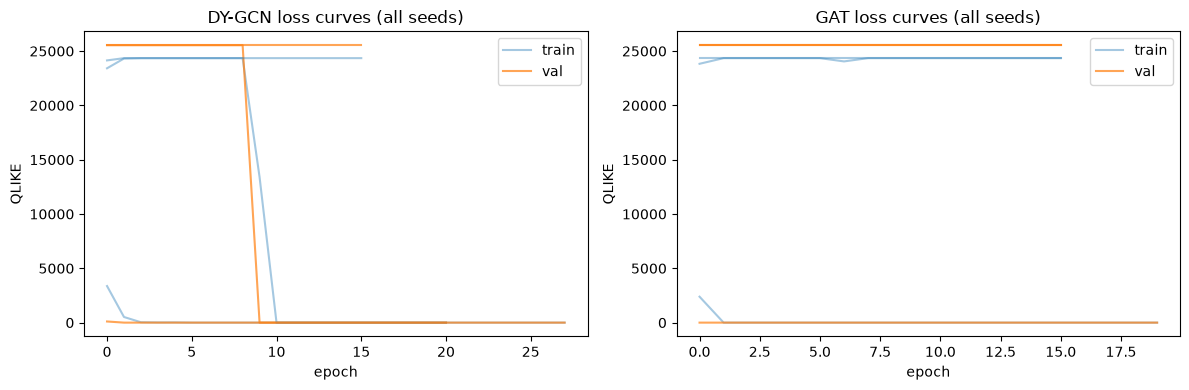

In [19]:
# Cell 16 — Train DY-GCN and GAT across multiple seeds, track loss curves
results = {"DY-GCN": [], "GAT": []}
histories = {"DY-GCN": [], "GAT": []}

for seed in SEEDS:
    m, h, v = train_with_early_stopping(DYGCN, seed)
    results["DY-GCN"].append(m); histories["DY-GCN"].append(h)

    m, h, v = train_with_early_stopping(SectorGAT, seed)
    results["GAT"].append(m); histories["GAT"].append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, hlist) in zip(axes, histories.items()):
    for i, h in enumerate(hlist):
        ax.plot(h["train"], alpha=0.4, color="tab:blue", label="train" if i == 0 else None)
        ax.plot(h["val"], alpha=0.7, color="tab:orange", label="val" if i == 0 else None)
    ax.set_title(f"{name} loss curves (all seeds)")
    ax.set_xlabel("epoch"); ax.set_ylabel("QLIKE")
    ax.legend()
plt.tight_layout()
plt.show()


In [20]:
# Cell 17 — Out-of-sample evaluation: QLIKE + pinball, averaged across seeds, plus HAR comparison
def predict_gnn(model, xs, ews, adj_list):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(len(xs)):
            if isinstance(model, DYGCN):
                p = model(xs[i], edge_index=edge_index_full, edge_weight=ews[i]) if model.use_pyg \
                    else model(xs[i], adj=adj_list[i])
            else:
                p = model(xs[i], edge_index=edge_index_full)
            preds.append(p.item())
    return np.array(preds)

def seed_avg_predictions(model_list, xs, ews, adj_list):
    all_preds = np.stack([predict_gnn(m, xs, ews, adj_list) for m in model_list])
    return all_preds.mean(axis=0)

test_y_np = test_y.numpy()
har_pred_np = har_pred_test.reindex(idx_test).values

pred_gcn = seed_avg_predictions(results["DY-GCN"], test_x, test_ew, test_adj)
pred_gat = seed_avg_predictions(results["GAT"], test_x, test_ew, test_adj)

def summarize(y_true, y_pred, label):
    t = torch.tensor(y_true, dtype=torch.float32)
    p = torch.tensor(np.clip(y_pred, 1e-6, None), dtype=torch.float32)
    return {"model": label,
            "QLIKE": round(qlike_loss(p, t).item(), 5),
            "Pinball@0.9": round(pinball_loss(p, t, quantile=TAIL_QUANTILE).item(), 5)}

metrics_table = pd.DataFrame([
    summarize(test_y_np, har_pred_np, "HAR"),
    summarize(test_y_np, pred_gcn, "DY-GCN"),
    summarize(test_y_np, pred_gat, "GAT"),
])
metrics_table


,model,QLIKE,Pinball@0.9
0,HAR,0.02064,0.00327
1,DY-GCN,30683.79102,0.02762
2,GAT,30683.79102,0.02762


### Statistical Assessment — Diebold-Mariano Test

In [21]:
# Cell 18 — Diebold-Mariano test: is GAT's improvement over DY-GCN / HAR statistically significant?
def diebold_mariano(y_true, pred_a, pred_b, loss="qlike", h=1):
    """DM test comparing forecast loss differential between model A and model B.
    Positive DM stat => model A has higher loss (worse) than model B."""
    y_true = np.asarray(y_true); pred_a = np.asarray(pred_a); pred_b = np.asarray(pred_b)
    eps = 1e-6
    if loss == "qlike":
        la = y_true / np.clip(pred_a, eps, None) - np.log(y_true / np.clip(pred_a, eps, None)) - 1
        lb = y_true / np.clip(pred_b, eps, None) - np.log(y_true / np.clip(pred_b, eps, None)) - 1
    else:
        la = (y_true - pred_a) ** 2
        lb = (y_true - pred_b) ** 2
    d = la - lb
    T = len(d)
    d_bar = d.mean()
    gamma0 = np.var(d, ddof=0)
    # Newey-West style variance with h-1 lag correction (h=1 => just gamma0)
    var_d = gamma0 / T
    dm_stat = d_bar / np.sqrt(var_d + eps)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return {"DM_stat": round(float(dm_stat), 4), "p_value": round(float(p_value), 5),
            "mean_loss_diff (A - B)": round(float(d_bar), 6)}

dm_results = pd.DataFrame([
    {"comparison": "GAT vs HAR", **diebold_mariano(test_y_np, pred_gat, har_pred_np)},
    {"comparison": "GAT vs DY-GCN", **diebold_mariano(test_y_np, pred_gat, pred_gcn)},
    {"comparison": "DY-GCN vs HAR", **diebold_mariano(test_y_np, pred_gcn, har_pred_np)},
])
dm_results


,comparison,DM_stat,p_value,mean_loss_diff (A - B)
0,GAT vs HAR,79.8973,0.0,30683.770573
1,GAT vs DY-GCN,0.0000,1.0,0.000000
2,DY-GCN vs HAR,79.8973,0.0,30683.770573


### Macro Regime-Split Comparison (Calm vs Turbulent)

In [22]:
# Cell 19 — Regime split: bifurcate test-set loss metrics across Calm vs Turbulent regimes
REGIME_TCI_QUANTILE = 0.75  # 🧪 EXPERIMENTATION HANDLE: [WHAT: TCI quantile defining "Turbulent" | WHY: 0.75 is a
                            # moderate stress cutoff | HOW: try 0.90 for a stricter "crisis-only" turbulent regime,
                            # or replace with a hard-coded stress-window mask from STRESS_WINDOWS instead]

tci_test = tci_series.reindex(idx_test)
turbulent_cut = tci_test.quantile(REGIME_TCI_QUANTILE)
regime_mask = tci_test > turbulent_cut  # True = turbulent

def regime_summary(mask, label_true):
    label = "Turbulent" if label_true else "Calm"
    idx_mask = mask.values if label_true else ~mask.values
    if idx_mask.sum() == 0:
        return None
    rows = []
    for name, preds in [("HAR", har_pred_np), ("DY-GCN", pred_gcn), ("GAT", pred_gat)]:
        s = summarize(test_y_np[idx_mask], preds[idx_mask], name)
        s["regime"] = label
        s["n_obs"] = int(idx_mask.sum())
        rows.append(s)
    return rows

regime_rows = (regime_summary(regime_mask, True) or []) + (regime_summary(regime_mask, False) or [])
regime_table = pd.DataFrame(regime_rows)[["regime", "model", "n_obs", "QLIKE", "Pinball@0.9"]]
regime_table


,regime,model,n_obs,QLIKE,Pinball@0.9
0,Turbulent,HAR,60,0.02348,0.00418
1,Turbulent,DY-GCN,60,33054.63281,0.02976
2,Turbulent,GAT,60,33054.63281,0.02976
3,Calm,HAR,180,0.01969,0.00297
4,Calm,DY-GCN,180,29893.51172,0.02691
5,Calm,GAT,180,29893.51172,0.02691


### Graph Interpretability — Learned GAT Attention vs Static DY Baseline

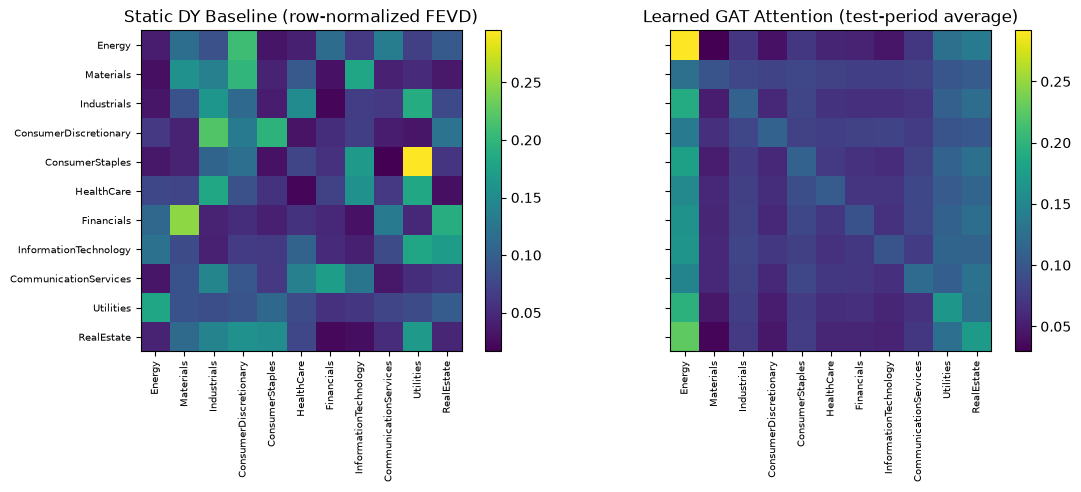

Exported: gat_vs_dy_attention_export.json


In [23]:
# Cell 20 — Export & plot learned GAT attention weights vs the static econometric DY baseline
def average_gat_attention(model, xs, ews, edge_index_full):
    model.eval()
    acc = torch.zeros(n, n)
    with torch.no_grad():
        for i in range(len(xs)):
            _ = model(xs[i], edge_index=edge_index_full)
            if model.use_pyg:
                ei, alpha = model.last_attention
                alpha = alpha.mean(dim=-1) if alpha.dim() > 1 else alpha  # average over heads
                for k in range(ei.shape[1]):
                    acc[ei[0, k], ei[1, k]] += alpha[k].item()
            else:
                acc += model.last_attention
    return (acc / len(xs)).numpy()

gat_attention_avg = average_gat_attention(results["GAT"][0], test_x, test_ew, edge_index_full)
dy_baseline_avg = dy_matrices[[panel.index.get_loc(d) for d in idx_test]].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(dy_baseline_avg, cmap="viridis")
axes[0].set_title("Static DY Baseline (row-normalized FEVD)")
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(SECTORS, rotation=90, fontsize=7)
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(SECTORS, fontsize=7)

im1 = axes[1].imshow(gat_attention_avg, cmap="viridis")
axes[1].set_title("Learned GAT Attention (test-period average)")
axes[1].set_xticks(range(n)); axes[1].set_xticklabels(SECTORS, rotation=90, fontsize=7)
axes[1].set_yticks(range(n)); axes[1].set_yticklabels([], fontsize=7)

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

attention_export = {
    "dy_baseline": dy_baseline_avg.tolist(),
    "gat_attention": gat_attention_avg.tolist(),
    "sectors": SECTORS,
}
with open("gat_vs_dy_attention_export.json", "w") as f:
    json.dump(attention_export, f, indent=2)
print("Exported: gat_vs_dy_attention_export.json")


## Summary

- **Line A** delivers the net directional spillover table, rolling TCI trajectory, stress-window shock
  reconstruction, sector role classification, and EPU/TPU policy-sensitivity diagnostics.
- **Line B** delivers a chronologically clean HAR / DY-GCN / GAT comparison with QLIKE + pinball loss,
  a Diebold-Mariano significance test, a Calm-vs-Turbulent regime split, and a GAT-vs-DY attention
  interpretability export.
- All tunable knobs are marked `🧪 EXPERIMENTATION HANDLE` inline — no need to hunt through the notebook
  to find what to sweep first (start with `HIDDEN_CHANNELS`, `LR`, and `TAIL_QUANTILE`).
